<a href="https://colab.research.google.com/github/Artem1965/DS23_Module3_Assignment1_Supervised_Learning/blob/main/DS23_Module3_Assignment1_Supervised_Starter_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 · Assignment 1 — Supervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.**
It gives you the skeleton of a professional supervised-learning workflow.
Your job is to fill in every `# TODO`, and — more importantly — to *interrogate*
your model and answer the guiding questions in `REPORT.md`.

> The model is the easy 30%. The thinking is the graded 70%.

**Workflow (6 stations):**
0. Frame the problem and pick a success metric
1. Load data, split honestly, build a dumb baseline
2. Train at least 3 model families
3. Evaluate once on the locked test set
4. Interrogate the model (errors, importance, stability)
5. Translate to the real world (Model Card)

Pick **one** task in Part 1. Write all code and comments in **English**.


---
## Part 0 · Frame the problem

Before any code, write in `REPORT.md`:
- The business question in one paragraph.
- The exact target you are predicting.
- The **primary metric** you will optimize, and **why it fits the business cost**
  (what does a false positive cost vs a false negative? for forecasting, what does
  an over- vs under-forecast cost?).

Do not skip this. A model optimized for the wrong metric is worse than no model.


---
## Part 1 · Setup, data, honest split, baseline

In [24]:
from google.colab import drive
drive.mount('/content/drive')

# Core imports. Add what you need; keep everything in English.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error,mean_absolute_percentage_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Choose ONE task

Uncomment exactly one loader below. Each returns the raw material you need;
**feature selection and engineering choices are yours** (keep it light — heavy
feature engineering is Module 5).

| Option | Type | Target | Notes |
|---|---|---|---|
| A | Binary classification | `review_score <= 2` (negative review) | The course thread. Try a **time-based split**. |
| B | Binary classification | customer churn | Fresh dataset. No class code to copy. |
| C | Forecasting (regression) | next-day order volume | Time series **as a supervised problem** (Session 18). |


In [25]:
# Set the path where your Olist CSVs live (the 9-table Kaggle structure from class).
OLIST_DIR =  '/content/drive/My Drive/BAR ILAN/Modules/Module 1_  AI Foundations and Ethics/2. Python and SQL for Data Science/Data/Brazilian E-Commerce Public Dataset by Olist/'



In [26]:

# ---- Option C · Olist daily order volume (forecasting as supervised) ----------
def load_olist_daily_volume(olist_dir=OLIST_DIR):
    """One row per calendar day with the number of orders placed that day.
    Turned into a supervised problem with lag/rolling features (Session 18)."""
    orders = pd.read_csv(olist_dir + "olist_orders_dataset.csv",
                         parse_dates=["order_purchase_timestamp"])
    daily = (orders.set_index("order_purchase_timestamp")
                   .resample("D").size().rename("n_orders").reset_index())
    daily = daily.rename(columns={"order_purchase_timestamp": "date"})
    # Keep the stable, well-populated period. The launch tail (until early Jan 2017)
# and the truncated end (after Aug 2018) are artifacts of incomplete data capture,
# not real demand — including them would distort baseline and training.
    daily = daily[(daily["date"] >= "2017-01-05") &
              (daily["date"] <= "2018-08-22")].reset_index(drop=True)

    # Lag and rolling features — all use shift(1+) so they rely ONLY on the past.
    daily["lag_1"] = daily["n_orders"].shift(1)
    daily["lag_7"] = daily["n_orders"].shift(7)
    daily["rolling_mean_7"] = daily["n_orders"].shift(1).rolling(7).mean()
    daily["rolling_mean_14"] = daily["n_orders"].shift(1).rolling(14).mean()

    # Calendar features.
    daily["day_of_week"] = daily["date"].dt.dayofweek
    daily["month"] = daily["date"].dt.month
    daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(int)

    # Drop rows with NaN created by the lag/rolling features (first 14 rows).
    daily = daily.dropna().reset_index(drop=True)
    return daily

df = load_olist_daily_volume()
print(df.shape)
print(df[["date", "n_orders"]].head())
print(df[["date", "n_orders"]].tail())

(581, 9)
        date  n_orders
0 2017-01-19        29
1 2017-01-20        29
2 2017-01-21        24
3 2017-01-22        31
4 2017-01-23        39
          date  n_orders
576 2018-08-18       198
577 2018-08-19       204
578 2018-08-20       256
579 2018-08-21       243
580 2018-08-22       187


In [27]:
# --- Leakage check: rolling features must end at D-1, never include day D ---
# A rolling window for predicting day D may only use data up to D-1.
# We recompute the window manually and compare to the stored feature value.
i = 100  # any row far enough from the start to have a full window

manual_roll7  = df["n_orders"].iloc[i-7:i].mean()    # days i-7 .. i-1 (excludes day i)
manual_roll14 = df["n_orders"].iloc[i-14:i].mean()   # days i-14 .. i-1 (excludes day i)

print("rolling_mean_7  matches manual (no leak):", np.isclose(df["rolling_mean_7"].iloc[i],  manual_roll7))
print("rolling_mean_14 matches manual (no leak):", np.isclose(df["rolling_mean_14"].iloc[i], manual_roll14))

rolling_mean_7  matches manual (no leak): True
rolling_mean_14 matches manual (no leak): True


In [46]:
# Inspect head and tail to find where stable volume begins/ends
print(df[["date", "n_orders"]].head(120).to_string())
print(df[["date", "n_orders"]].tail(30).to_string())

          date  n_orders
0   2017-01-19        29
1   2017-01-20        29
2   2017-01-21        24
3   2017-01-22        31
4   2017-01-23        39
5   2017-01-24        40
6   2017-01-25        63
7   2017-01-26        86
8   2017-01-27        62
9   2017-01-28        29
10  2017-01-29        35
11  2017-01-30        53
12  2017-01-31        70
13  2017-02-01        73
14  2017-02-02        69
15  2017-02-03        60
16  2017-02-04        67
17  2017-02-05        75
18  2017-02-06        85
19  2017-02-07       112
20  2017-02-08        95
21  2017-02-09        77
22  2017-02-10        66
23  2017-02-11        49
24  2017-02-12        64
25  2017-02-13        78
26  2017-02-14        76
27  2017-02-15        62
28  2017-02-16        55
29  2017-02-17        46
30  2017-02-18        54
31  2017-02-19        40
32  2017-02-20        63
33  2017-02-21        41
34  2017-02-22        63
35  2017-02-23        59
36  2017-02-24        64
37  2017-02-25        43
38  2017-02-26        46


In [29]:
print(df[df["date"] >= "2018-08-01"][["date", "n_orders"]].to_string())


          date  n_orders
559 2018-08-01       311
560 2018-08-02       302
561 2018-08-03       314
562 2018-08-04       245
563 2018-08-05       276
564 2018-08-06       372
565 2018-08-07       370
566 2018-08-08       316
567 2018-08-09       289
568 2018-08-10       256
569 2018-08-11       188
570 2018-08-12       197
571 2018-08-13       292
572 2018-08-14       316
573 2018-08-15       288
574 2018-08-16       320
575 2018-08-17       257
576 2018-08-18       198
577 2018-08-19       204
578 2018-08-20       256
579 2018-08-21       243
580 2018-08-22       187


### Honest split + dumb baseline

This is the station that answers *"is my model worth anything?"*.

- **Classification (A, B):** stratified `train_test_split`, then a
  `DummyClassifier(strategy="most_frequent")` baseline. Record its score.
- **Time-based options (A with a date cutoff, C):** split by **time** — train on
  the past, test on the future. A random split here *leaks the future* (Session 18).
  Baseline for forecasting = a naive model (e.g. "tomorrow = today" or seasonal naive).

Keep the test set **locked** until Part 3.


In [30]:
# TODO: build X, y from df (your feature choice), then split.

feature_cols = [c for c in df.columns if c not in ("n_orders", "date")]
X = df[ feature_cols ]
y = df["n_orders"]

# TODO: time-based alternative (Option C, or Option A with a cutoff date):
cutoff = df["date"].quantile(0.8)
train = df[df["date"] <= cutoff]
test  = df[df["date"] >  cutoff]

X_train, y_train = train[feature_cols], train["n_orders"]
X_test,  y_test  = test[feature_cols],  test["n_orders"]

print("train:", train["date"].min(), "→", train["date"].max(), "| n =", len(train))
print("test :", test["date"].min(),  "→", test["date"].max(),  "| n =", len(test))

naive_pred  = X_test["lag_1"]   # random walk
snaive_pred = X_test["lag_7"]   # seasonal naive


snaive_mae  = mean_absolute_error(y_test, snaive_pred)
snaive_rmse = np.sqrt(mean_squared_error(y_test, snaive_pred))
naive_mae  = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

baseline_score = naive_rmse   # use YOUR primary metric, not accuracy by default

print("Seasonal-naive baseline — RMSE:", round(snaive_rmse, 2), "| MAE:", round(snaive_mae, 2))
print("Baseline score (chosen = random-walk RMSE):", round(baseline_score, 2))
print("Random-walk  (lag_1) — RMSE:", round(naive_rmse, 2), "| MAE:", round(naive_mae, 2))

train: 2017-01-19 00:00:00 → 2018-04-28 00:00:00 | n = 465
test : 2018-04-29 00:00:00 → 2018-08-22 00:00:00 | n = 116
Seasonal-naive baseline — RMSE: 64.04 | MAE: 49.79
Baseline score (chosen = random-walk RMSE): 49.09
Random-walk  (lag_1) — RMSE: 49.09 | MAE: 37.38


---
## Part 2 · Build at least three model families

Use the algorithms from Sessions 16-18. Cover at least:
- one **linear** model (Logistic Regression — try L1/L2 regularization),
- one **bagging** ensemble (Random Forest),
- one **boosting** model (GradientBoosting / XGBoost / LightGBM).

Select with **cross-validation** (`StratifiedKFold` for classification). Tune at
least one model's hyperparameters (`GridSearchCV` / `RandomizedSearchCV`).

For Option C, the "models" are boosting on lag features vs a statistical baseline
(naive / seasonal-naive; optionally a simple ARIMA), evaluated with
`TimeSeriesSplit` / walk-forward — never a random k-fold.


In [31]:
# TODO: instantiate and cross-validate your models. Keep results in a dict.

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV

# CV strategy (replace StratifiedKFold)
tscv = TimeSeriesSplit(n_splits=5)

# Model 1: Ridge (inside a Pipeline because it needs scaling)
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0))
    ])
# Model 2: RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Model 3: GradientBoostingRegressor
gb = GradientBoostingRegressor(
    n_estimators= 200,
    learning_rate= 0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

# Cross-validate all three (X_train / y_train only!)
SCORING = "neg_root_mean_squared_error"


cv_scores = {}

for name, model in [("Ridge", ridge_pipe), ("RF", rf), ("GB", gb)]:
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring=SCORING)
    cv_scores[name] = abs(scores.mean())
    print(f"{name:6s}  CV RMSE: {abs(scores.mean()):.2f} ± {scores.std():.2f}")

cv_scores




Ridge   CV RMSE: 50.50 ± 35.22
RF      CV RMSE: 120.11 ± 111.00
GB      CV RMSE: 167.26 ± 185.24


{'Ridge': np.float64(50.497071337580124),
 'RF': np.float64(120.10729046428455),
 'GB': np.float64(167.25608653354794)}

In [32]:
# --- Part 2 diagnostic: why do tree models fail? ---

# 1. Trend check: compare mean of first vs second half of y_train.
#    A big jump means the series drifts upward over time.
print("First half mean :", y_train[:len(y_train)//2].mean().round(1))
print("Second half mean:", y_train[len(y_train)//2:].mean().round(1))

# 2. Per-fold RMSE for GB: see which folds break.
#    TimeSeriesSplit folds are ordered in time, so a spike in later
#    folds points to extrapolation failure (trees can't predict
#    values higher than anything seen in training).
gb_scores = cross_val_score(gb, X_train, y_train, cv=tscv, scoring=SCORING)
print("GB per-fold RMSE:", [round(abs(s), 1) for s in gb_scores])

First half mean : 102.1
Second half mean: 210.0
GB per-fold RMSE: [np.float64(41.1), np.float64(36.1), np.float64(131.7), np.float64(530.8), np.float64(96.5)]


In [33]:
# TODO: tune at least one model's hyperparameters with cross-validation.
from sklearn.model_selection import GridSearchCV

param_grid = {"ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]}

tscv = TimeSeriesSplit(n_splits=5)

grid_ridge = GridSearchCV(
    estimator=ridge_pipe,   # Pipeline(StandardScaler + Ridge)
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Best alpha:", grid_ridge.best_params_)
print("Best CV RMSE:", -grid_ridge.best_score_)



Best alpha: {'ridge__alpha': 10}
Best CV RMSE: 49.89038911588014


---
## Part 3 · Honest evaluation on the locked test set

Touch the test set **once**. Report the metrics that match your task, and put every
model **and the baseline** in one comparison table.

- Classification: confusion matrix, precision, recall, F1, ROC-AUC, PR curve.
- Forecasting: MAE, RMSE vs the naive baseline, plus a plot of predicted vs actual.


In [34]:
# === Part 3 setup: fit final models on the FULL training set ===
# cross_val_score in Part 2 only scored internal copies — these objects
# are still unfitted. Fit them once on all training data before touching test.
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
# grid_ridge.best_estimator_ is ALREADY fitted (refit=True did it). Do NOT re-fit.

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [35]:
print((y_test == 0).sum())
print(y_test.min())

0
91


In [44]:
# === Part 3 · Restore the calendar index =============================
# X_train/X_test lost their dates during feature building (they carry a
# plain RangeIndex). The dates still live in train["date"] / test["date"].
# Re-attach them so Part 3 plots use a real time axis.
# No refit, no re-split, no feature change — index only.
# Required upstream: train, test, X_train, X_test, y_train, y_test, naive_pred
# =====================================================================

idx_train = pd.DatetimeIndex(pd.to_datetime(train["date"].values), name="date")
idx_test  = pd.DatetimeIndex(pd.to_datetime(test["date"].values),  name="date")

# Anti-leakage guard: train must end strictly before test begins
assert idx_train.max() < idx_test.min(), "LEAKAGE: train dates reach into test"

# Re-attach the dates (copies, so upstream stays intact)
X_train = X_train.copy(); X_train.index = idx_train
X_test  = X_test.copy();  X_test.index  = idx_test
y_train = pd.Series(np.asarray(y_train), index=idx_train, name="n_orders")
y_test  = pd.Series(np.asarray(y_test),  index=idx_test,  name="n_orders")
naive_pred = pd.Series(np.asarray(naive_pred), index=idx_test, name="naive_pred")

print("Index restored:")
print(f"  train : {idx_train.min().date()} -> {idx_train.max().date()}  n={len(idx_train)}")
print(f"  test  : {idx_test.min().date()} -> {idx_test.max().date()}  n={len(idx_test)}")

Index restored:
  train : 2017-01-19 -> 2018-04-28  n=465
  test  : 2018-04-29 -> 2018-08-22  n=116


In [37]:

# Compute all three regression metrics for one model
# =====================================================================
# PART 3 - HONEST EVALUATION ON THE LOCKED TEST SET
# The test set is touched exactly once, here.
# STRICTLY NO .fit() IN THIS CELL - prediction and scoring only.
# Required upstream: X_test, y_test, naive_pred, grid_ridge, rf, gb
# Requires mean_absolute_percentage_error in the Part 0 import block.
# =====================================================================

# ---------- BLOCK A - PREDICTIONS (was entirely missing) -------------
# This is the ONLY place in the notebook where the test set is predicted.
best_ridge = grid_ridge.best_estimator_          # refit=True already fitted it

y_pred_naive = pd.Series(np.asarray(naive_pred, dtype=float),
                         index=y_test.index, name="naive_rw")
y_pred_ridge = pd.Series(best_ridge.predict(X_test), index=y_test.index, name="ridge")
y_pred_rf    = pd.Series(rf.predict(X_test),         index=y_test.index, name="rf")
y_pred_gb    = pd.Series(gb.predict(X_test),         index=y_test.index, name="gb")


# ---------- BLOCK B - METRICS ----------------------------------------
# Compute all regression metrics for one model.
# R2 is deliberately excluded: on a trending series it mostly rewards
# following the trend, not genuine forecast skill.
def reg_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae":  mean_absolute_error(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred) * 100,   # to percent
        "bias": float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),  # signed
    }

# Build rows: baseline first, then the three models
rows = [
    {"model": "naive_rw", **reg_metrics(y_test, y_pred_naive)},
    {"model": "ridge",    **reg_metrics(y_test, y_pred_ridge)},
    {"model": "rf",       **reg_metrics(y_test, y_pred_rf)},
    {"model": "gb",       **reg_metrics(y_test, y_pred_gb)},
]

results_test = pd.DataFrame(rows).set_index("model").sort_values("rmse").round(2)

print("PART 3 - TEST SET RESULTS  (2018-04-29 .. 2018-08-22, n=116)")
print(results_test.to_string())

# ---------- Skill relative to the naive bar --------------------------
print("\nSKILL VS NAIVE  (positive = better than naive)")
n_rmse = results_test.loc["naive_rw", "rmse"]
n_mae  = results_test.loc["naive_rw", "mae"]
for m in results_test.index:
    if m == "naive_rw":
        continue
    print(f"  {m:<10} RMSE {(n_rmse - results_test.loc[m,'rmse'])/n_rmse*100:+6.1f}%"
          f"   MAE {(n_mae - results_test.loc[m,'mae'])/n_mae*100:+6.1f}%")

# ---------- CV vs TEST: does CV predict test performance? ------------
print("\nCV RMSE vs TEST RMSE")
cv_rmse = {"naive_rw": 49.09, "ridge": 49.89, "rf": 120.0, "gb": 167.0}
for m in results_test.index:
    t = results_test.loc[m, "rmse"]
    print(f"  {m:<10} CV {cv_rmse[m]:>7.2f}   TEST {t:>7.2f}   delta {t - cv_rmse[m]:>+7.2f}")

# ---------- Leakage smell test ---------------------------------------
print("\nSANITY CHECK")
best = results_test.index[0]
if results_test.loc[best, "mape"] < 3:
    print("  *** MAPE below 3% on a daily series - THIS SMELLS LIKE LEAKAGE ***")
else:
    print(f"  best = {best}, MAPE = {results_test.loc[best,'mape']:.2f}% - plausible")
print(f"  test mean = {y_test.mean():.1f} orders/day")

PART 3 - TEST SET RESULTS  (2018-04-29 .. 2018-08-22, n=116)
           rmse    mae   mape   bias
model                               
ridge     41.14  32.36  15.84  -4.48
naive_rw  49.09  37.38  17.37  -0.16
rf        60.92  35.50  16.77   2.95
gb        78.92  42.09  20.39  12.99

SKILL VS NAIVE  (positive = better than naive)
  ridge      RMSE  +16.2%   MAE  +13.4%
  rf         RMSE  -24.1%   MAE   +5.0%
  gb         RMSE  -60.8%   MAE  -12.6%

CV RMSE vs TEST RMSE
  ridge      CV   49.89   TEST   41.14   delta   -8.75
  naive_rw   CV   49.09   TEST   49.09   delta   +0.00
  rf         CV  120.00   TEST   60.92   delta  -59.08
  gb         CV  167.00   TEST   78.92   delta  -88.08

SANITY CHECK
  best = ridge, MAPE = 15.84% - plausible
  test mean = 221.9 orders/day


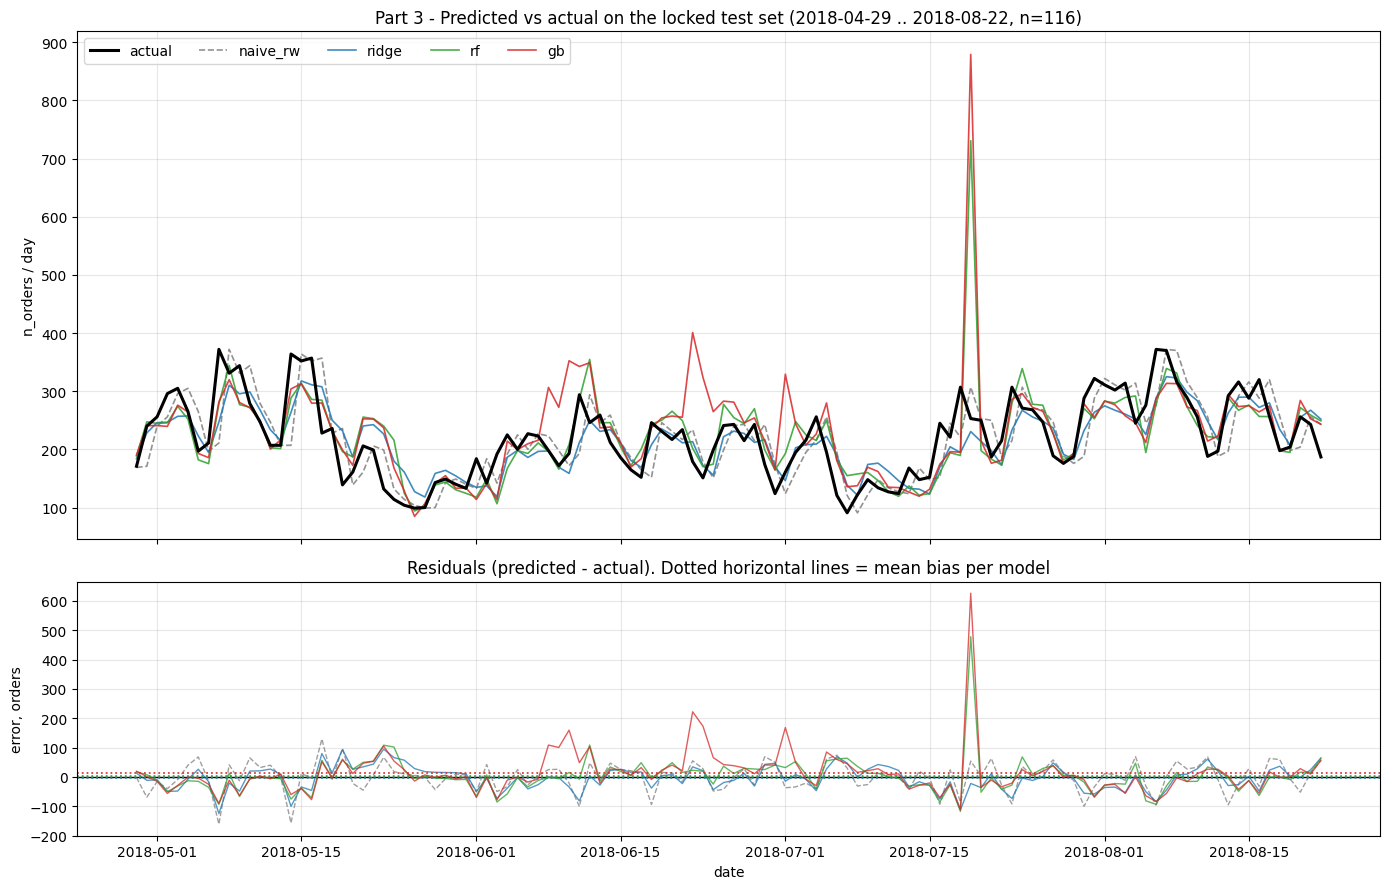

RESIDUAL BIAS BY HALF OF THE TEST WINDOW
  first  half : 2018-04-29 .. 2018-06-25
  second half : 2018-06-26 .. 2018-08-22

  model        bias_h1   bias_h2     drift
  naive_rw       -1.24      0.93     +2.17
  ridge          -2.53     -6.44     -3.91
  rf              0.84      5.06     +4.22
  gb             15.88     10.11     -5.77

  actual level : h1 mean = 214.7, h2 mean = 229.1, change = +14.4


In [39]:
# =====================================================================
# PART 3 - PREDICTED VS ACTUAL ON A TIME AXIS
# Required by the assignment: "plus a plot of predicted vs actual".
# READ-ONLY: no .fit(), no .predict() here - it reuses the y_pred_*
# Series already produced by the metrics cell.
# Required upstream: y_test, y_pred_naive, y_pred_ridge, y_pred_rf, y_pred_gb
# =====================================================================

preds = {
    "naive_rw": (y_pred_naive, "tab:gray",  "--"),
    "ridge":    (y_pred_ridge, "tab:blue",  "-"),
    "rf":       (y_pred_rf,    "tab:green", "-"),
    "gb":       (y_pred_gb,    "tab:red",   "-"),
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

# ---------- Panel 1: actual vs predicted ------------------------------
ax = axes[0]
ax.plot(y_test.index, y_test.values, color="black", lw=2.2,
        label="actual", zorder=5)
for name, (yp, color, style) in preds.items():
    ax.plot(yp.index, yp.values, color=color, ls=style, lw=1.2,
            alpha=0.85, label=name)

ax.set_title("Part 3 - Predicted vs actual on the locked test set "
             f"({y_test.index.min().date()} .. {y_test.index.max().date()}, "
             f"n={len(y_test)})")
ax.set_ylabel("n_orders / day")
ax.legend(ncol=5, loc="upper left")
ax.grid(alpha=0.3)

# ---------- Panel 2: residuals (predicted - actual) -------------------
# A flat cloud around zero = unbiased. A sloping cloud = the model is
# carrying a trend the test window does not have.
ax = axes[1]
ax.axhline(0, color="black", lw=1)
for name, (yp, color, style) in preds.items():
    resid = yp - y_test
    ax.plot(resid.index, resid.values, color=color, ls=style, lw=1.0,
            alpha=0.75, label=name)
    ax.axhline(resid.mean(), color=color, ls=":", lw=1.3, alpha=0.9)

ax.set_title("Residuals (predicted - actual). "
             "Dotted horizontal lines = mean bias per model")
ax.set_ylabel("error, orders")
ax.set_xlabel("date")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- Diagnostic: is the bias constant or drifting? -------------
# Hypothesis under test: tree models over-predict because they extend an
# upward trend learned on train into a test window that has plateaued.
# If true, the bias should GROW from the first half to the second.
half = len(y_test) // 2
print("RESIDUAL BIAS BY HALF OF THE TEST WINDOW")
print(f"  first  half : {y_test.index[0].date()} .. {y_test.index[half-1].date()}")
print(f"  second half : {y_test.index[half].date()} .. {y_test.index[-1].date()}")
print(f"\n  {'model':<10} {'bias_h1':>9} {'bias_h2':>9} {'drift':>9}")
for name, (yp, _, _) in preds.items():
    r = (yp - y_test).values
    b1, b2 = r[:half].mean(), r[half:].mean()
    print(f"  {name:<10} {b1:>9.2f} {b2:>9.2f} {b2 - b1:>+9.2f}")

print(f"\n  actual level : h1 mean = {y_test.values[:half].mean():.1f}, "
      f"h2 mean = {y_test.values[half:].mean():.1f}, "
      f"change = {y_test.values[half:].mean() - y_test.values[:half].mean():+.1f}")

---
## Part 4 · Interrogate the model

This is where data scientists are made. Do all four:

1. **Error analysis** — pull the 5 worst mistakes. What do they share? Data issue or hard case?
2. **Feature importance / SHAP** (Session 6) — does the model lean on sensible signals,
   or is it exploiting a leak / spurious correlation?
3. **Stability** — how much does the score vary across CV folds? Would you trust the number?
4. **Bias-variance read** — compare train vs test/CV. Over- or under-fitting?


In [40]:
# TODO 1 · Error analysis: find the worst predictions and inspect them.
# Regression version of the scaffold. predict_proba does not exist on a
# regressor: for classification "wrongness" was |proba - y_true|, here it
# is |predicted - actual| in orders/day. Predictions come from Part 3.

best_model = best_ridge          # ridge won on the test set (RMSE 41.14)

cols = ["y_true", "p", "wrongness", "lag_1", "rolling_mean_7", "day_of_week"]

for name, y_pred in [("naive_rw", y_pred_naive), ("ridge", y_pred_ridge),
                     ("rf", y_pred_rf), ("gb", y_pred_gb)]:
    p = y_pred                                            # replaces predict_proba
    err = X_test.assign(y_true=y_test.values, p=p.values.round(1))
    err["wrongness"] = (err["p"] - err["y_true"]).abs()
    print(f"\n--- {name}: 5 worst predictions ---")
    print(err.sort_values("wrongness", ascending=False).head(5)[cols].to_string())

# Is the error spread across the window, or driven by a single day?
print("\n--- error concentration ---")
for name, y_pred in [("naive_rw", y_pred_naive), ("ridge", y_pred_ridge),
                     ("rf", y_pred_rf), ("gb", y_pred_gb)]:
    r = y_pred - y_test
    worst = r.abs().idxmax()
    rmse    = np.sqrt((r ** 2).mean())
    rmse_wo = np.sqrt((r.drop(index=worst) ** 2).mean())
    print(f"{name:<9} worst = {worst.date()}  residual = {r.loc[worst]:+7.1f}  "
          f"RMSE {rmse:6.2f} -> {rmse_wo:6.2f} without it")


--- naive_rw: 5 worst predictions ---
            y_true      p  wrongness  lag_1  rolling_mean_7  day_of_week
date                                                                    
2018-05-07     372  211.0      161.0  211.0      252.857143            0
2018-05-14     364  207.0      157.0  207.0      283.857143            0
2018-05-17     228  357.0      129.0  357.0      287.571429            3
2018-06-11     294  193.0      101.0  193.0      205.428571            0
2018-07-30     288  188.0      100.0  188.0      235.142857            0

--- ridge: 5 worst predictions ---
            y_true      p  wrongness  lag_1  rolling_mean_7  day_of_week
date                                                                    
2018-05-07     372  247.1      124.9  211.0      252.857143            0
2018-07-18     307  194.5      112.5  221.0      169.285714            2
2018-05-14     364  263.6      100.4  207.0      283.857143            0
2018-05-23     132  226.6       94.6  199.0      

In [41]:
# TODO 2 · Feature importance or SHAP.
# import shap
# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test)


In [42]:
# TODO 3 · Stability across folds (report mean and std), and
# TODO 4 · train-vs-test gap for your best model. Write the conclusion in REPORT.md.


---
## Part 5 · Model Card (fill this in, then copy to REPORT.md)

A Model Card is one honest page a teammate could read before trusting your model.
Fill every field. "Unknown" with a reason is an acceptable, professional answer.


In [43]:
MODEL_CARD = """
# Model Card

## 1. Overview
- Task / business question:
- Dataset (which option) and time range:
- Target definition:

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast):
- Dumb baseline score:
- Best model score (on the locked test set):
- Did it beat the baseline meaningfully? Is it worth deploying?

## 3. What the model relies on
- Top features and whether they make business sense:
- Any feature you suspect is a leak or spurious? How did you check?

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern?
- Where would this model break?
- Stability across folds (mean +/- std):

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model?

## 6. Real world
- If deployed Monday: what would you monitor? What triggers a retrain?
- With two more weeks / more data, what would you do next?
"""
print(MODEL_CARD)



# Model Card

## 1. Overview
- Task / business question:
- Dataset (which option) and time range:
- Target definition:

## 2. Metric & performance
- Primary metric and WHY (business cost of FP vs FN / over- vs under-forecast):
- Dumb baseline score:
- Best model score (on the locked test set):
- Did it beat the baseline meaningfully? Is it worth deploying?

## 3. What the model relies on
- Top features and whether they make business sense:
- Any feature you suspect is a leak or spurious? How did you check?

## 4. Limitations & failure modes
- The 5 worst errors — what is the pattern?
- Where would this model break?
- Stability across folds (mean +/- std):

## 5. Fairness / ethics
- Could any group be systematically mis-served by this model?

## 6. Real world
- If deployed Monday: what would you monitor? What triggers a retrain?
- With two more weeks / more data, what would you do next?



---
### Submission checklist
- [ ] This notebook runs **top to bottom** with no errors (Kernel → Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] A dumb baseline is present and compared in one table.
- [ ] The test set was touched exactly once.
- [ ] `REPORT.md` answers all guiding questions and contains the filled Model Card.

Good luck — and stay skeptical of your own results.
